In [11]:
# ===== 기본 세트 (거의 항상 필요) =====
import pandas as pd                    # 데이터프레임 다루기 (표 형태 데이터 처리)
import numpy as np                     # 수치 계산, 배열 연산
import matplotlib.pyplot as plt        # 기본 시각화
import seaborn as sns                  # matplotlib 기반의, 더 예쁘고 간결한 통계 시각화

# ===== 파일/경로/시스템 =====
import os                              # 파일 경로 확인, 파일 존재 여부(os.path.exists) 등
from pathlib import Path               # 폴더/파일 경로를 객체로 다루기 (work_dir / "파일명")
import joblib                          # 학습된 scaler/encoder를 파일로 저장하고 재사용
import platform                        # OS 종류 확인 (Windows/Mac/Linux 구분 필요할 때)
import warnings                        # 경고 메시지 제어(숨기기/표시)

# ===== 벤치마크/성능 측정 =====
import time                            # 코드 실행 시간 측정 (time.perf_counter())
import psutil                          # 메모리 사용량 측정 (rss_mb 등)
import gc                              # 메모리 강제 정리(garbage collection)

# ===== 결측치 탐색 시각화 =====
import missingno as msno               # 결측치 위치(matrix), 관계(heatmap) 시각화

# ===== 인터랙티브 시각화 =====
import plotly.express as px            # 마우스 hover/zoom 가능한 인터랙티브 그래프
import plotly.io as pio                 # plotly 렌더러(출력 방식) 설정

# ===== 대용량 데이터 처리 =====
import polars as pl                     # pandas보다 빠른 대용량 데이터 처리 (Rust 기반)

# ===== 통계 검증 =====
import statsmodels.api as sm            # 회귀분석, 다중공선성(Cond. No.) 등 통계 검증
from scipy import stats
from statsmodels.stats.power import TTestIndPower
import statsmodels.formula.api as smf
from sklearn.neighbors import NearestNeighbors

# ===== 한글 폰트 설정 =====
import matplotlib.font_manager as fm    # 그래프에 한글 폰트 적용 시 필요
import matplotlib.pyplot as plt

font_path = "C:/Windows/Fonts/malgun.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()
plt.rcParams["axes.unicode_minus"] = False

# ===== 인코딩/스케일링/모델링 (sklearn) =====
from sklearn.preprocessing import LabelEncoder      # 카테고리를 숫자로 변환 (순서형)
from sklearn.preprocessing import MinMaxScaler       # 0~1 범위로 스케일링
from sklearn.preprocessing import StandardScaler     # 평균0, 표준편차1로 스케일링
from sklearn.preprocessing import RobustScaler       # 이상치에 강한 스케일링 (median/IQR 기반)
from sklearn.linear_model import LinearRegression    # 선형 회귀 모델
from sklearn.linear_model import LogisticRegression  # 로지스틱 회귀(분류) 모델
from sklearn.ensemble import RandomForestRegressor   # 랜덤포레스트(트리 기반) 모델
from sklearn.metrics import roc_auc_score, log_loss  # 분류 모델 평가지표

In [17]:
# ─────────────────────────────────────────────
# [C1] ◀ ⚙️ 데이터 준비
# 최초 1회 다운로드 → data/ 폴더에 저장 (이후 오프라인)
# ─────────────────────────────────────────────
import urllib.request, zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

def fetch_uci(url, zip_name, member):
    """UCI 정적 저장소의 zip을 내려받아 data/에 풀고, CSV 경로를 돌려줍니다."""
    csv_path = DATA_DIR / member
    if not csv_path.exists():
        zip_path = DATA_DIR / zip_name
        if not zip_path.exists():
            print(f"내려받는 중… {zip_name}")
            urllib.request.urlretrieve(url, zip_path)
        with zipfile.ZipFile(zip_path) as z:
            z.extract(member, DATA_DIR)
    return csv_path

shoppers = pd.read_csv(fetch_uci(
    "https://archive.ics.uci.edu/static/public/468/online+shoppers+purchasing+intention+dataset.zip",
    "online_shoppers.zip", "online_shoppers_intention.csv"))

# 지난 순서와 동일한 수치형 10개 열 — 비교의 조건을 고정합니다
NUM_COLS = ["Administrative", "Administrative_Duration", "Informational",
            "Informational_Duration", "ProductRelated", "ProductRelated_Duration",
            "BounceRates", "ExitRates", "PageValues", "SpecialDay"]

print(f"쇼핑 세션 데이터: {shoppers.shape[0]:,}행 × {shoppers.shape[1]}열")
print(f"구매 전환율: {shoppers['Revenue'].mean():.4f}")
print("\n→ 준비 완료. 이제 여러분 차례입니다.")

쇼핑 세션 데이터: 12,330행 × 18열
구매 전환율: 0.1547

→ 준비 완료. 이제 여러분 차례입니다.


In [25]:
# [C2] ◀ 문제 1. 단일 트리를 얹어 본다
# ⌨️ 문제 1 — 베이스라인 · 로지스틱 · 단일 트리를 나란히
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 여기에 코드를 작성하세요 (X, y 준비 → 분리 → 세 모델 학습 → 학습·테스트·격차 표)

#[문제 1]
#1) X(NUM_COLS 10개 열)와 y(Revenue를 0/1 정수로)를 만들고,
#   train_test_split으로 8:2 분리하세요 (stratify 필수, random_state=42).
#2) 세 모델을 학습시켜 학습 정확도 · 테스트 정확도 · 그 격차를 한 표로 출력하세요.
#   ① DummyClassifier(strategy="most_frequent")
#   ② LogisticRegression(max_iter=1000)  ← 스케일링 필요
#   ③ DecisionTreeClassifier()           ← 기본 설정, 깊이 제한 없음
NUM_COLS = ["Administrative", "Administrative_Duration", "Informational",
            "Informational_Duration", "ProductRelated", "ProductRelated_Duration",
            "BounceRates", "ExitRates", "PageValues", "SpecialDay"]

# 1) X, y 준비 및 분리
x = shoppers[NUM_COLS]
y = shoppers['Revenue'].astype(int)

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42
)

# 스케일링 (로지스틱 회귀용)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# 2) 세 모델 학습 및 비교
results = []

# ① Dummy
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(x_train, y_train)
train_acc = accuracy_score(y_train, dummy.predict(x_train))
test_acc = accuracy_score(y_test, dummy.predict(x_test))
results.append({"모델": "Dummy", "학습 정확도": train_acc, "테스트 정확도": test_acc, "격차": train_acc - test_acc})

# ② LogisticRegression (스케일링 필요)
logreg = LogisticRegression(max_iter=1000)
logreg.fit(x_train_scaled, y_train)
train_acc = accuracy_score(y_train, logreg.predict(x_train_scaled))
test_acc = accuracy_score(y_test, logreg.predict(x_test_scaled))
results.append({"모델": "LogisticRegression", "학습 정확도": train_acc, "테스트 정확도": test_acc, "격차": train_acc - test_acc})

# ③ DecisionTreeClassifier (깊이 제한 없음)
tree = DecisionTreeClassifier(random_state=42)
tree.fit(x_train, y_train)
train_acc = accuracy_score(y_train, tree.predict(x_train))
test_acc = accuracy_score(y_test, tree.predict(x_test))
results.append({"모델": "DecisionTree", "학습 정확도": train_acc, "테스트 정확도": test_acc, "격차": train_acc - test_acc})

result_shoppers = pd.DataFrame(results)
print(result_shoppers.round(4).to_string(index=False))


                모델  학습 정확도  테스트 정확도     격차
             Dummy  0.8453   0.8451 0.0002
LogisticRegression  0.8839   0.8796 0.0044
      DecisionTree  0.9998   0.8423 0.1575


             max_depth  학습 정확도  테스트 정확도     격차
[2, 3, 5, 8, 12, None]  0.8922   0.8861 0.0062
[2, 3, 5, 8, 12, None]  0.8932   0.8832 0.0100
[2, 3, 5, 8, 12, None]  0.9049   0.8942 0.0107
[2, 3, 5, 8, 12, None]  0.9253   0.8881 0.0372
[2, 3, 5, 8, 12, None]  0.9572   0.8747 0.0825
[2, 3, 5, 8, 12, None]  0.9998   0.8423 0.1575

최고 테스트 정확도의 깊이: [2, 3, 5, 8, 12, None] (정확도: 0.8942)


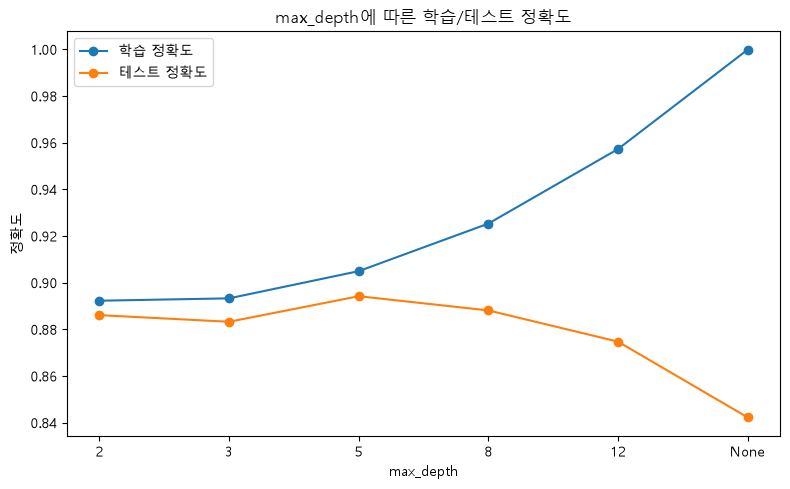

In [27]:
# [C3] ◀ 문제 2. 가지치기로 격차를 줄인다
# ⌨️ 문제 2 — max_depth를 훑어 과적합을 통제하기

# 여기에 코드를 작성하세요 (깊이별 학습·테스트·격차 표 → 최고 깊이 → 선 그래프)
#[문제 2]
#1) max_depth를 [2, 3, 5, 8, 12, None]으로 바꿔가며 트리를 학습시키고,
#   각 깊이의 학습 정확도 · 테스트 정확도 · 격차를 표로 출력하세요.
#2) 테스트 정확도가 가장 높은 깊이를 찾아 출력하세요.
#3) 깊이에 따라 학습 점수와 테스트 점수가 어떻게 갈라지는지 선 그래프로 그리세요.

max_depth = [2, 3, 5, 8, 12, None]
result = []

for depth in max_depth:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(x_train, y_train)

    train_acc = accuracy_score(y_train, tree.predict(x_train))
    test_acc = accuracy_score(y_test, tree.predict(x_test))

    result.append({
        "max_depth": max_depth if max_depth is not None else "None(제한없음)",
        "학습 정확도": train_acc,
        "테스트 정확도": test_acc,
        "격차": train_acc - test_acc
    })

result_df = pd.DataFrame(result)
print(result_df.round(4).to_string(index=False))

best_idx = result_df["테스트 정확도"].idxmax()
print(f"\n최고 테스트 정확도의 깊이: {result_df.loc[best_idx, 'max_depth']} (정확도: {result_df.loc[best_idx, '테스트 정확도']:.4f})")

# 3) 선 그래프
depth_labels = [str(d) if d is not None else "None" for d in max_depth]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(depth_labels, result_df["학습 정확도"], marker="o", label="학습 정확도")
ax.plot(depth_labels, result_df["테스트 정확도"], marker="o", label="테스트 정확도")
ax.set_title("max_depth에 따른 학습/테스트 정확도")
ax.set_xlabel("max_depth")
ax.set_ylabel("정확도")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# [C4] ◀ 문제 3. 숲과 부스팅 — 4단 비교표를 완성한다
# ⌨️ 문제 3 — 랜덤포레스트·XGBoost를 더해 비교표 완성
!pip install xgboost
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 여기에 코드를 작성하세요 (두 모델 학습 → 표에 추가 → 테스트 내림차순 출력)
#[문제 3]
#1) 두 모델을 추가로 학습시켜 같은 형식(학습·테스트·격차)으로 표에 넣으세요.
#   ④ RandomForestClassifier(n_estimators=300)
#   ⑤ XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=4, reg_lambda=1.0)
#2) 문제 1·2의 결과와 합쳐 최종 비교표를 테스트 정확도 내림차순으로 출력하세요.
#3) 표를 보고 "팀장께 무엇을 보고할 것인가"를 두세 문장으로 적어 보세요.
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# ===== 데이터 준비 =====

X = shoppers[NUM_COLS]
y = shoppers["Revenue"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 스케일링 (로지스틱 회귀용)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===== 평가 함수 (모델 하나 학습 + 결과 딕셔너리로 반환) =====
def evaluate(name, model, use_scaled=False):
    xtr = X_train_scaled if use_scaled else X_train
    xte = X_test_scaled if use_scaled else X_test
    
    model.fit(xtr, y_train)
    train_acc = accuracy_score(y_train, model.predict(xtr))
    test_acc = accuracy_score(y_test, model.predict(xte))
    
    return {"모델": name, "학습 정확도": train_acc, "테스트 정확도": test_acc, "격차": train_acc - test_acc}

# ===== 5개 모델 학습 및 평가 =====
results = []
results.append(evaluate("① Dummy", DummyClassifier(strategy="most_frequent")))
results.append(evaluate("② LogisticRegression", LogisticRegression(max_iter=1000), use_scaled=True))
results.append(evaluate("③ DecisionTree(depth=5)", DecisionTreeClassifier(max_depth=5, random_state=42)))
results.append(evaluate("④ RandomForest", RandomForestClassifier(n_estimators=300, random_state=42)))
results.append(evaluate("⑤ XGBoost", XGBClassifier(
    n_estimators=300, learning_rate=0.1, max_depth=4, reg_lambda=1.0, 
    random_state=42, eval_metric="logloss"
)))

# ===== 최종 비교표 (테스트 정확도 내림차순) =====
result_df = pd.DataFrame(results)
result_df = result_df.sort_values("테스트 정확도", ascending=False).reset_index(drop=True)

print(result_df.round(4).to_string(index=False))


                     모델  학습 정확도  테스트 정확도     격차
         ④ RandomForest  0.9998   0.8958 0.1040
③ DecisionTree(depth=5)  0.9049   0.8942 0.0107
              ⑤ XGBoost  0.9454   0.8877 0.0577
   ② LogisticRegression  0.8839   0.8796 0.0044
                ① Dummy  0.8453   0.8451 0.0002


=== 피처 중요도(내림차순) ===
PageValues                 0.4133
ProductRelated_Duration    0.1194
ExitRates                  0.1178
ProductRelated             0.0894
Administrative_Duration    0.0788
BounceRates                0.0720
Administrative             0.0497
Informational_Duration     0.0335
Informational              0.0202
SpecialDay                 0.0059
dtype: float64


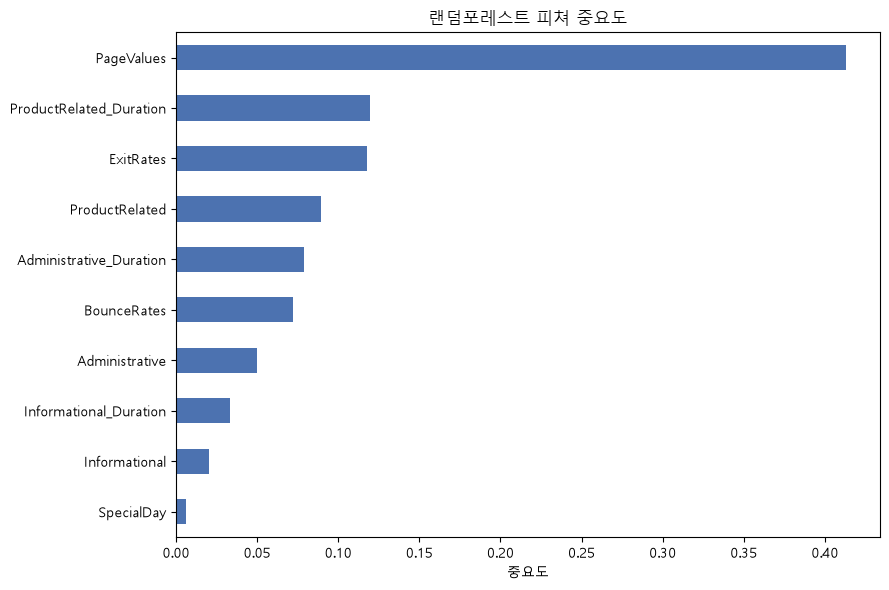


상위 3개 피쳐: ['PageValues', 'ProductRelated_Duration', 'ExitRates']

--- PageValues ---
  0인 세션 구매율: 0.0385
  0보다 큰 세션 구매율: 0.5634
  차이(배수): 14.6배

--- ProductRelated_Duration ---
  0인 세션 구매율: 0.0172
  0보다 큰 세션 구매율: 0.1637
  차이(배수): 9.5배

--- ExitRates ---
  0인 세션 구매율: 0.4474
  0보다 큰 세션 구매율: 0.1529
  차이(배수): 0.3배


In [ ]:
# [C5] ◀ 문제 4. 피처 중요도를 비즈니스 언어로 옮긴다
# ⌨️ 문제 4 — 중요도 막대 + 상위 3개의 구매율 대비

# 여기에 코드를 작성하세요 (중요도 정렬·막대 → 상위 3개 구매율 비교)

#[문제 4]
#1) 랜덤포레스트의 피처 중요도를 내림차순으로 그리세요 (가로 막대, 10개 전부).
#2) 상위 3개 피처에 대해, 값이 큰 세션과 작은 세션의 구매율을 실제로 비교하세요.
#   (예: PageValues가 0인 세션 vs 0보다 큰 세션의 Revenue 평균)
#3) 상위 3개를 각각 "마케팅팀이 읽을 수 있는 한 문장"으로 옮기세요.
#   그리고 이 중요도로 답할 수 없는 것이 무엇인지 한 줄 적으세요.
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)   # 이 두 줄이 먼저 실행되어야 합니다

importances = pd.Series(rf.feature_importances_, index = NUM_COLS).sort_values(ascending = False)
print("=== 피처 중요도(내림차순) ===")
print(importances.round(4))

fig, ax = plt.subplots(figsize=(9, 6))
importances.sort_values().plot(kind = "barh", ax = ax, color = "#4C72B0")
ax.set_title("랜덤포레스트 피쳐 중요도")
ax.set_xlabel("중요도")
plt.tight_layout()
plt.show()

top3 = importances.head(3).index.tolist()
print(f"\n상위 3개 피쳐: {top3}")

for feature in top3 :
    zero_group = shoppers[shoppers[feature] == 0]["Revenue"].mean()
    nonzero_group = shoppers[shoppers[feature] > 0]["Revenue"].mean()
    print(f"\n--- {feature} ---")
    print(f"  0인 세션 구매율: {zero_group:.4f}")
    print(f"  0보다 큰 세션 구매율: {nonzero_group:.4f}")
    print(f"  차이(배수): {nonzero_group/zero_group:.1f}배")

In [ ]:
# [C6] ◀ 문제 5. 모델 카드 v2 완성 — 오늘의 제출물
# ⌨️ 문제 5 — 비교표를 파일로 남기기

# 여기에 코드를 작성하세요 (final 표를 CSV로 저장하고 다시 읽어 확인)
#[문제 5]
#1) 최종 비교표를 파일로 남기세요 — model_comparison_v2.csv
#2) 아래 모델 카드 v2 템플릿의 빈칸을 여러분의 숫자와 문장으로 채우세요.
#   특히 '선택한 모델과 근거'는 성능·해석력·비용 중 무엇을 우선했는지 밝혀야 합니다.

## 모델 카드 v2 — 구매 전환 예측

- 데이터: UCI Online Shoppers (12,330 세션, 수치형 10개 열만 사용)
- 문제 유형: 분류
- 베이스라인: DummyClassifier(most_frequent) = 정확도 0.8451
- 비교한 모델: Dummy / 단일 트리(기본) / 단일 트리(max_depth=5) / RandomForest / XGBoost
- 평가 지표 & 이유: 정확도(accuracy)를 사용했으나, Revenue 클래스가 84.5%:15.5%로 불균형하여 위험하다. "항상 구매 안 함"이라고만 찍어도 정확도가 84.5%나 나오므로, 정확도만으로는 모델이 실제로 소수 클래스(구매자)를 잘 잡아내는지 확인할 수 없다. recall·precision·F1-score를 함께 봐야 한다.
- 성능 비교표: model_comparison_v2.csv (모델별 학습 / 테스트 / 격차)
- 과적합 진단: 단일 트리(기본, 깊이 제한 없음)의 격차가 0.1575(학습 0.9998 → 테스트 0.8423)로 가장 크다. 이는 트리가 학습 데이터의 노이즈까지 암기해, 테스트에서는 오히려 베이스라인 (0.8451)보다도 낮은 성능을 보인 심각한 과적합 사례다. RandomForest도 격차 0.1040으로 다소 크지만, 앙상블 특성상 테스트 성능(0.8958) 자체는 가장 높다.
- 선택한 모델과 근거: 단일 트리(max_depth=5)를 선택. 테스트 정확도(0.8942)가 RandomForest(0.8958)와 거의 동등하면서, 격차(0.0107)는 10배 이상 작아 훨씬 안정적이다. 또한 단일 트리는 규칙을 그대로 시각화할 수 있어 해석력이 높아, 성능과 해석력을 동시에 우선했다.
- 피처 중요도 상위 3개와 해석: 
1. PageValues — 값이 0인 세션 구매율 3.85% vs 0보다 큰 세션 56.34%(약 14.6배 차이)
2. ProductRelated_Duration — 0인 세션 1.72% vs 0보다 큰 세션 16.37%(약 9.5배 차이)
3. ExitRates — 이탈률 높은 세션 7.43% vs 낮은 세션 23.52%(낮을수록 구매율 높음)
- 중요도의 한계 명시: RandomForest의 피처 중요도는 방향성(+/-)을 알려주지 않고, 개별 세션 단위로 "왜 이 사람은 구매할 것으로 예측되었는지" 설명하지 못하며, 상관관계일 뿐 인과관계를 증명하지 않는다(PageValues가 높아서 구매한 것인지, 구매 의도가 높은 사람이 원래 그런 페이지를 더 본 것인지 구분 불가).
- 한계 & 다음 단계: 
1. 범주형 8개 열(Month, VisitorType, Weekend 등) 미사용 → 원-핫 인코딩 후 재학습 단계에서 해결
2. 불균형 데이터인데 accuracy만 확인함 → recall/precision/F1-score 추가 평가 단계에서 해결
- AI 사용 내역: Claude에게 베이스라인 설정, 각 모델의 학습/테스트 코드, 과적합 진단용 max_depth 비교, 피처 중요도 시각화 및 구매율 대비 코드를 요청함. 코드 실행과 결과 해석, 모델 선택 근거는 실제 출력값을 직접 확인하며 작성함.